In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist

In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Flatten,Conv2D, MaxPooling2D
from tensorflow.keras.utils import to_categorical

In [20]:
train_df=pd.read_csv("fashion-mnist_train.csv")
test_df=pd.read_csv("fashion-mnist_test.csv")

In [21]:
train_df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [22]:
train_x=train_df.drop('label',axis=1)
train_y=train_df['label']

test_x=test_df.drop('label',axis=1)
test_y=test_df['label']

In [23]:
print(train_x.shape)
print(train_y.shape)
print(test_x.shape)
print(test_y.shape)

(60000, 784)
(60000,)
(10000, 784)
(10000,)


In [24]:
train_x=train_x.values.reshape(-1,28,28,1)
test_x=test_x.values.reshape(-1,28,28,1)

In [25]:
print(train_x.shape)
print(train_y.shape)
print(test_x.shape)
print(test_y.shape)

(60000, 28, 28, 1)
(60000,)
(10000, 28, 28, 1)
(10000,)


In [26]:
train_x=train_x.astype('float32')/255.0
test_x=test_x.astype('float32')/255.0

In [27]:
train_y.value_counts()

label
2    6000
9    6000
6    6000
0    6000
3    6000
4    6000
5    6000
8    6000
7    6000
1    6000
Name: count, dtype: int64

In [28]:
#building model
model=Sequential()

#1-1st convo
model.add(Conv2D(32,kernel_size=(3,3),activation='relu',input_shape=(28,28,1)))
#2- frist max
model.add(MaxPooling2D(pool_size=(2,2)))
#3- 2nd convo
model.add(Conv2D(64,kernel_size=(3,3),activation='relu'))
#4- 2nd pool
model.add(MaxPooling2D(pool_size=(2,2)))
#5- flatten
model.add(Flatten())
#6- hidden layer
model.add(Dense(128,activation='relu'))
#7- output layer
model.add(Dense(10,activation='softmax'))

C:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [30]:
#compile the model
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [31]:
#fit model- train
model.fit(train_x,train_y,validation_split=0.2,epochs=5)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 25s 15ms/step - accuracy: 0.7581 - loss: 0.6744 - val_accuracy: 0.8677 - val_loss: 0.3663
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.8810 - loss: 0.3298 - val_accuracy: 0.8778 - val_loss: 0.3239
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 22s 15ms/step - accuracy: 0.8994 - loss: 0.2740 - val_accuracy: 0.9013 - val_loss: 0.2751
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - accuracy: 0.9136 - loss: 0.2335 - val_accuracy: 0.8943 - val_loss: 0.2817
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - accuracy: 0.9238 - loss: 0.2048 - val_accuracy: 0.9096 - val_loss: 0.2613


In [32]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 675,104 (2.58 MB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 450,070 (1.72 MB)

In [33]:
loss,accuracy=model.evaluate(test_x,test_y)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9048 - loss: 0.2605


In [34]:
print(accuracy)

0.9097999930381775


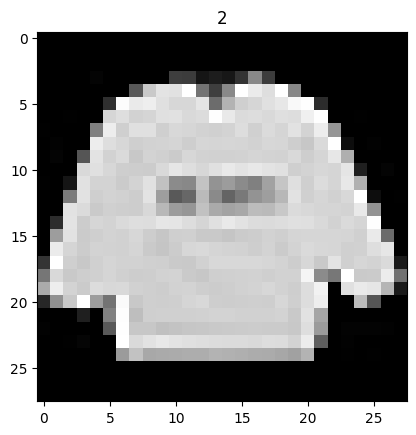

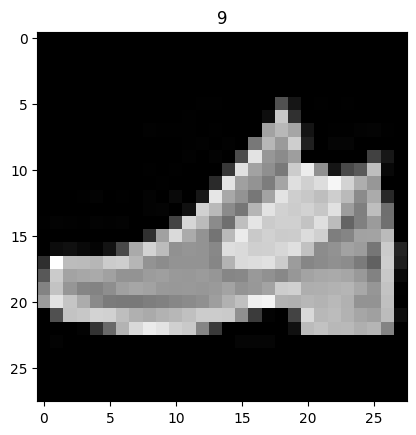

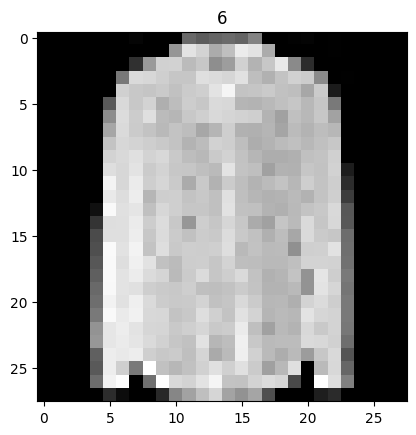

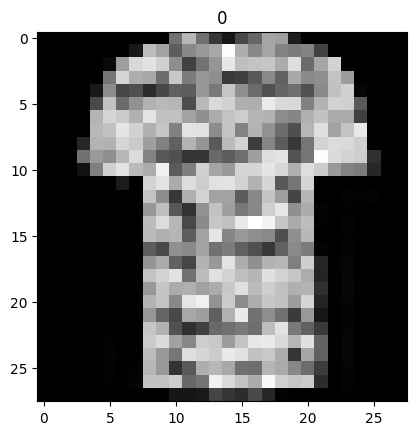

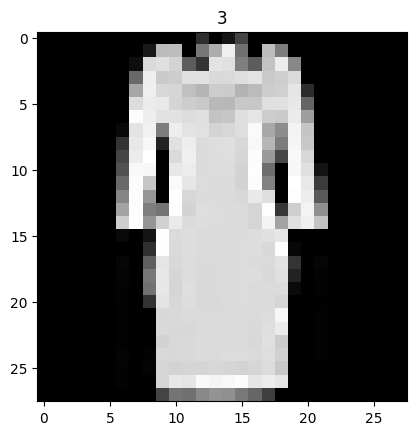

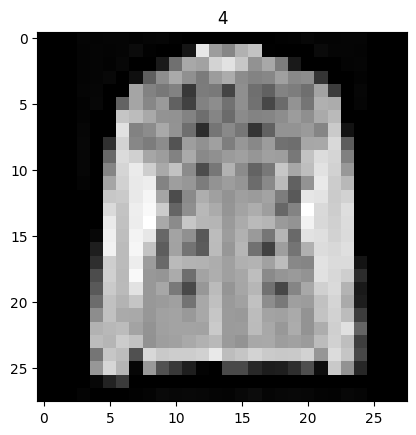

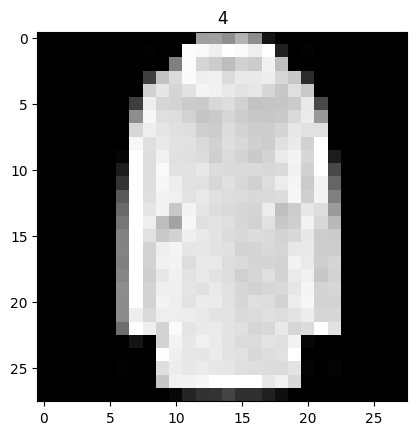

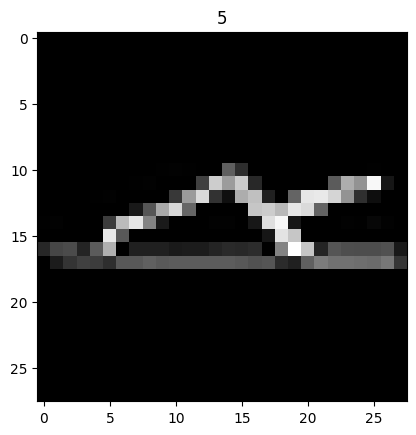

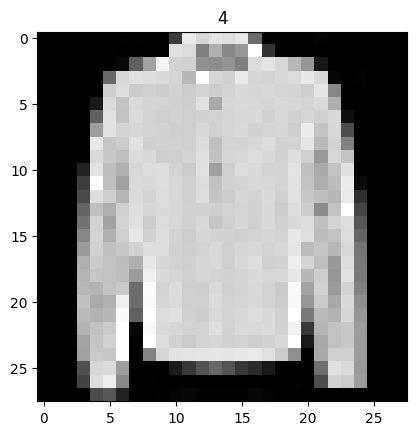

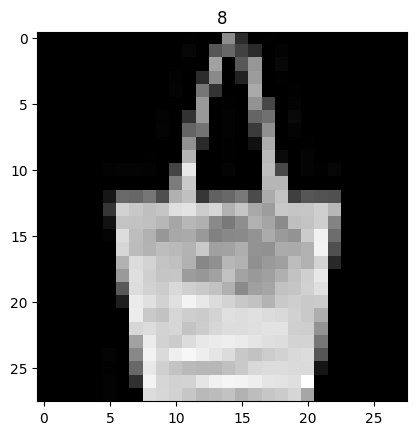

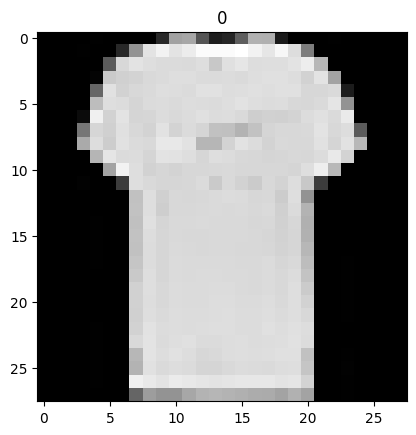

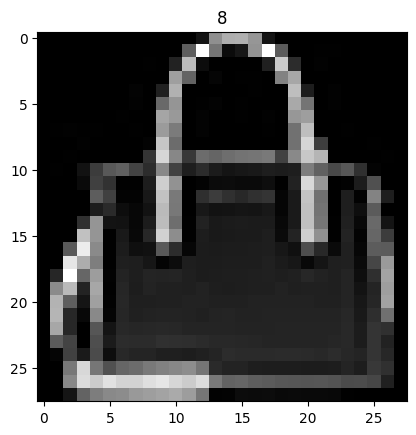

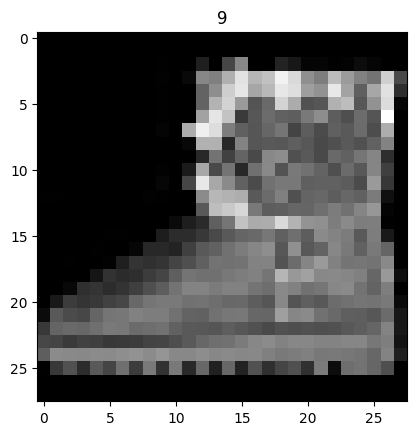

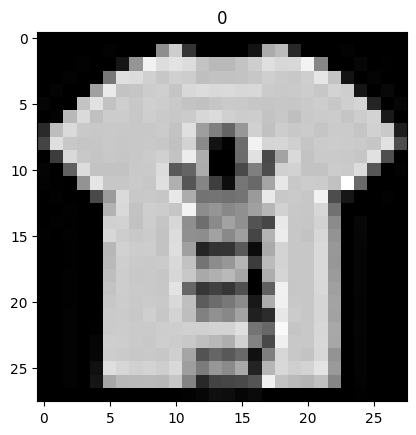

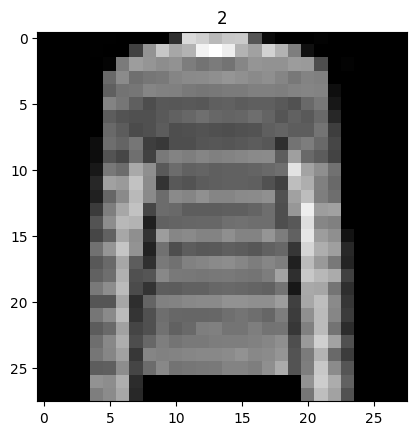

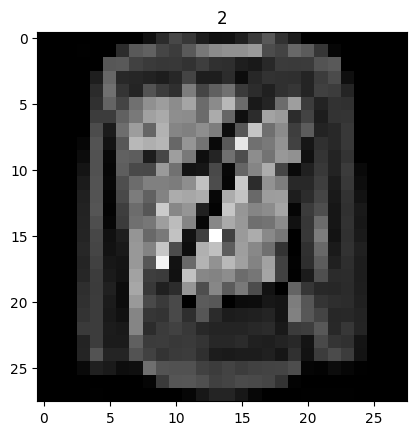

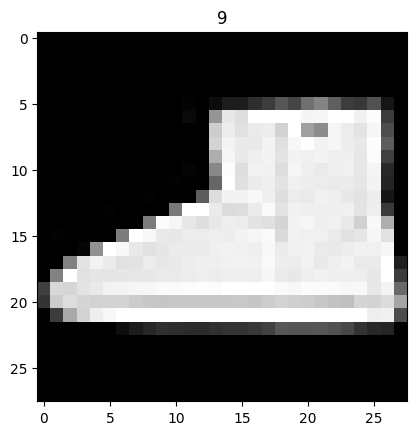

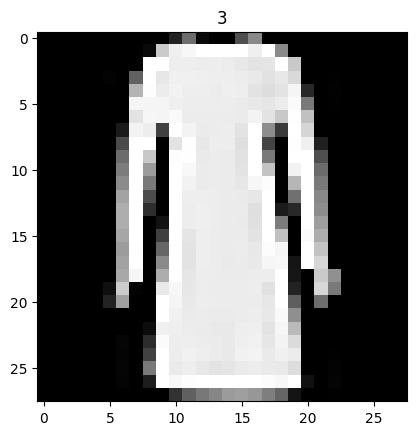

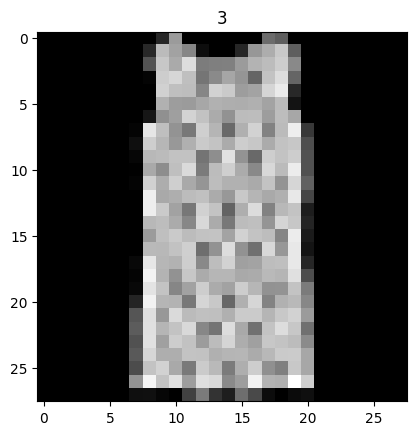

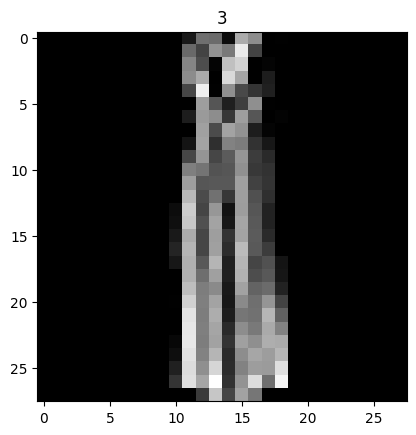

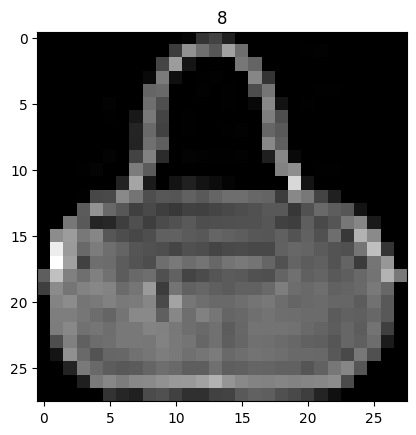

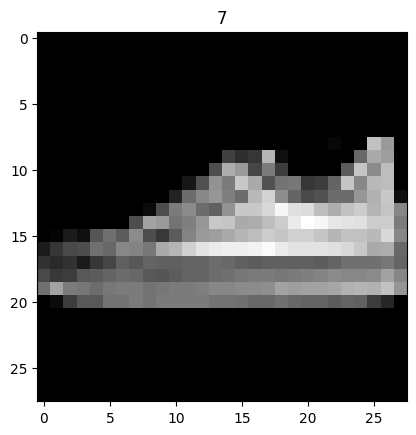

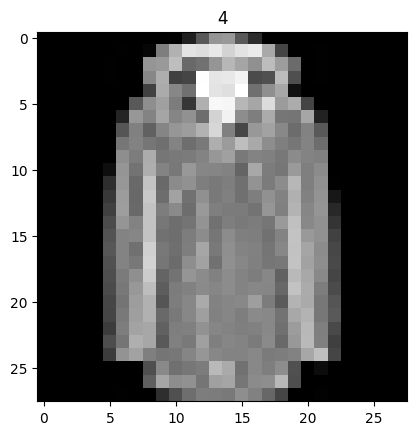

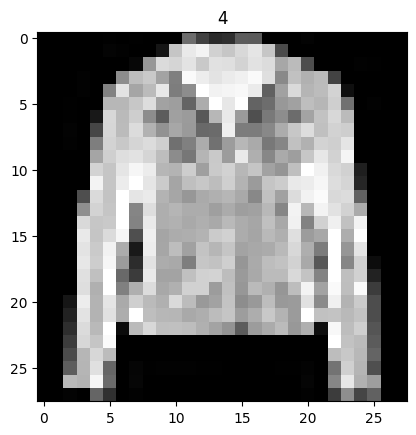

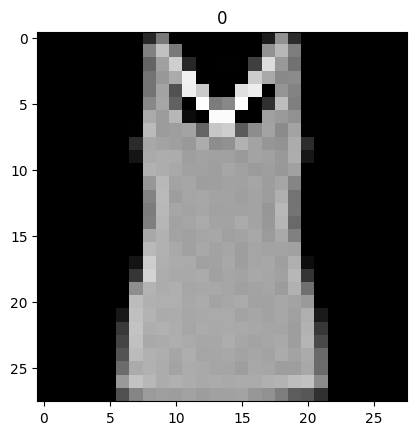

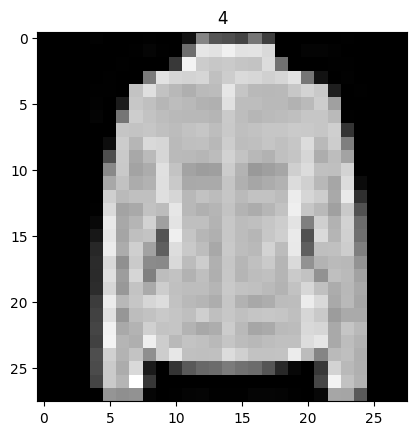

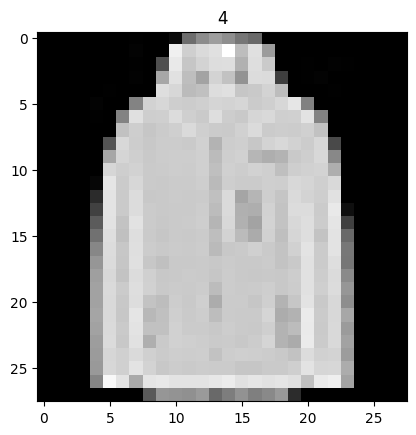

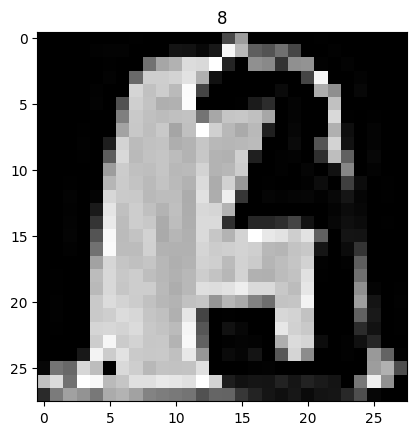

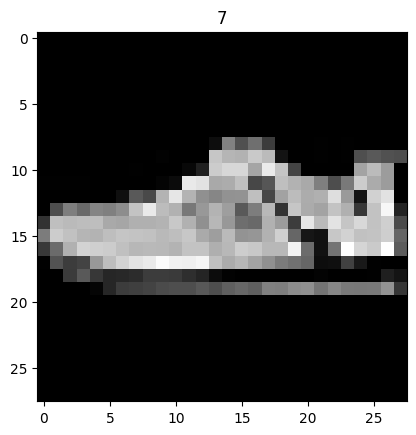

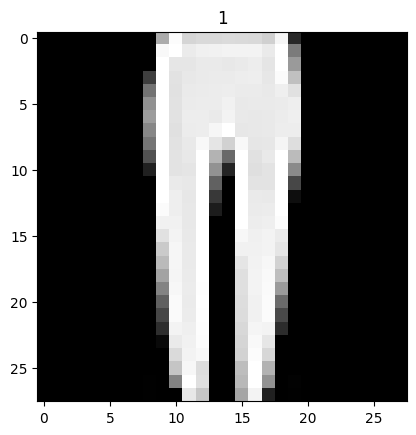

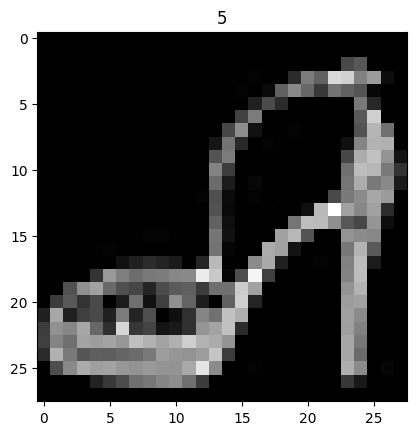

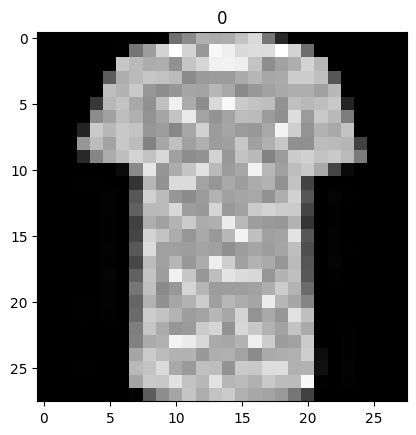

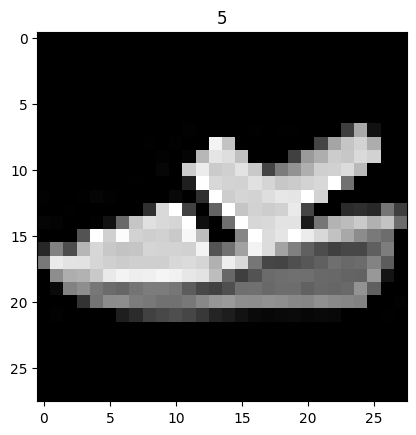

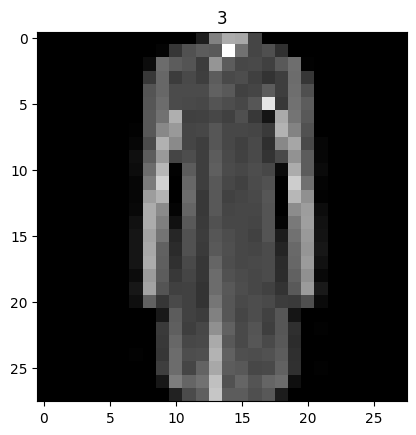

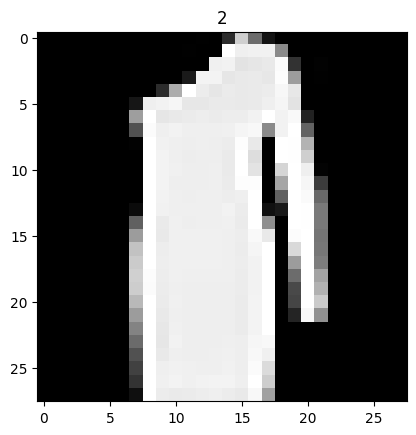

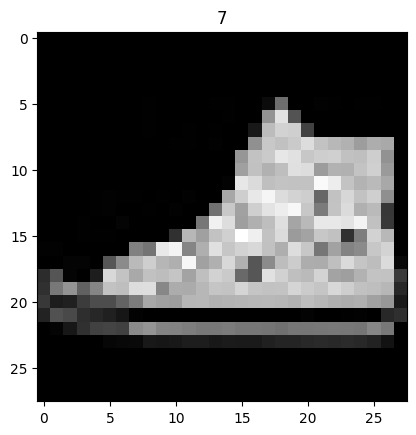

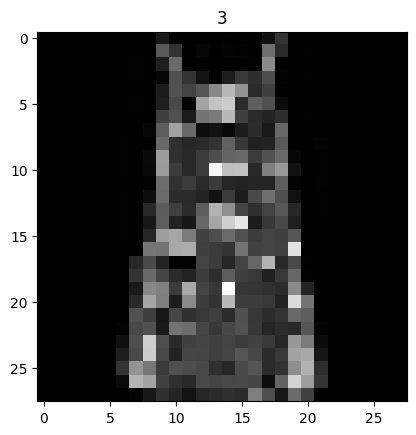

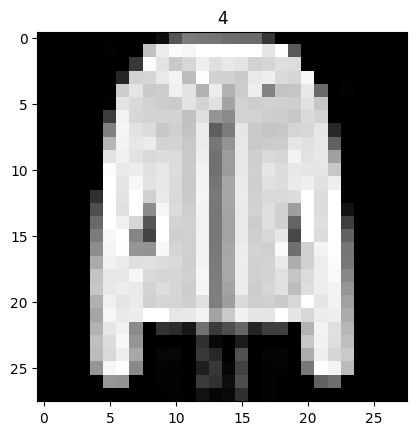

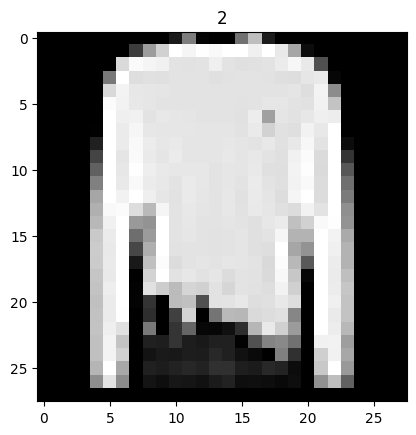

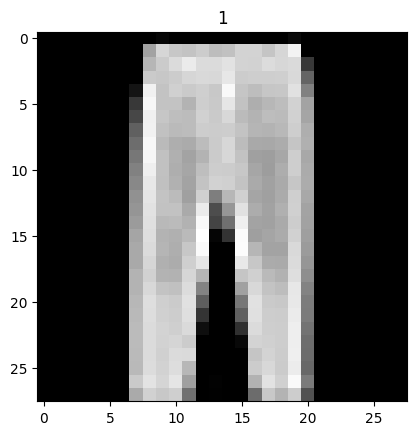

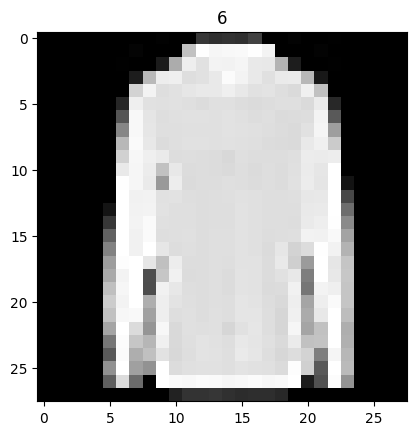

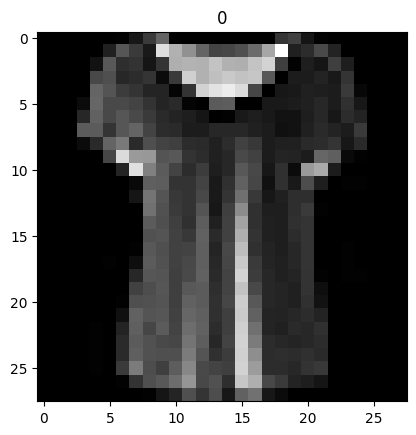

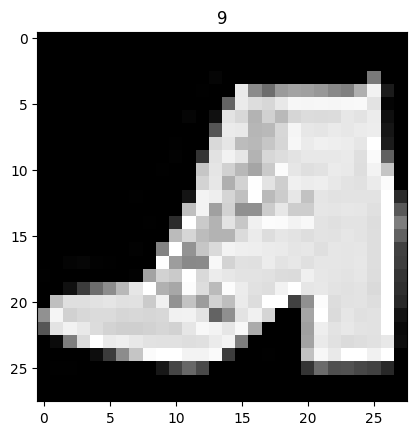

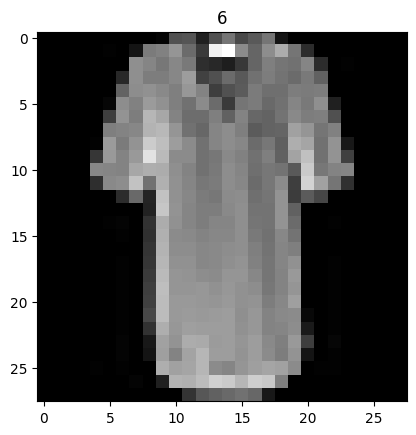

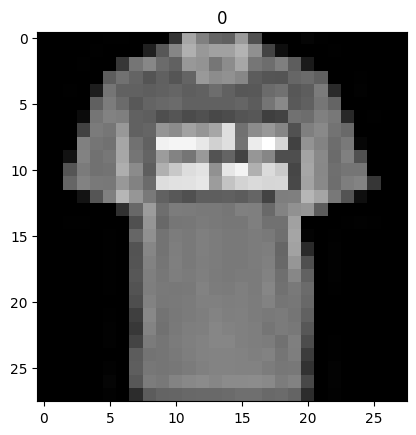

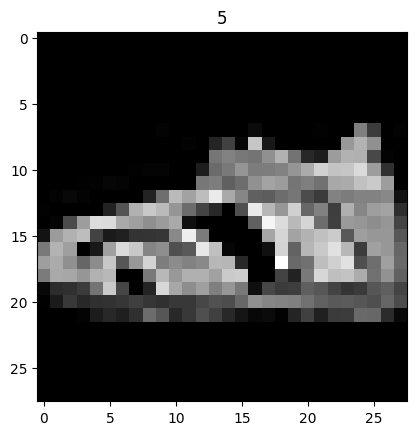

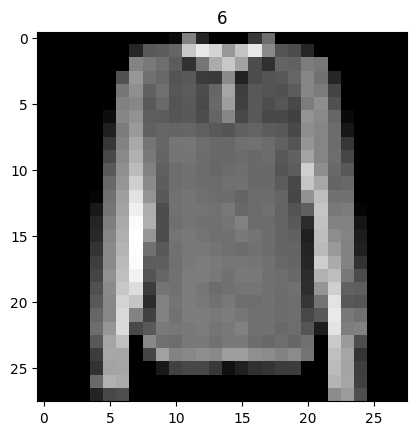

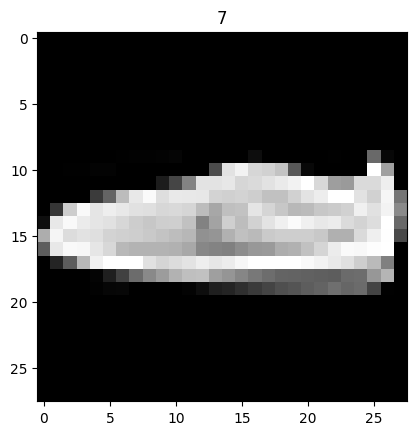

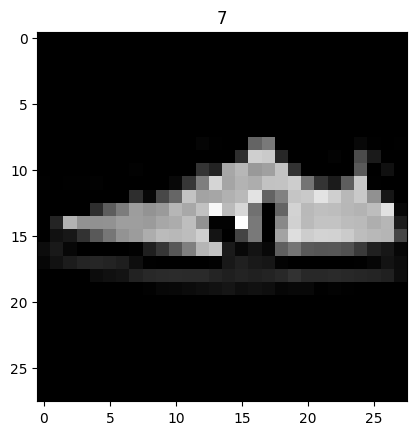

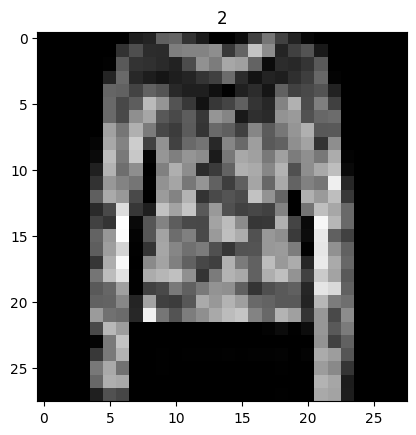

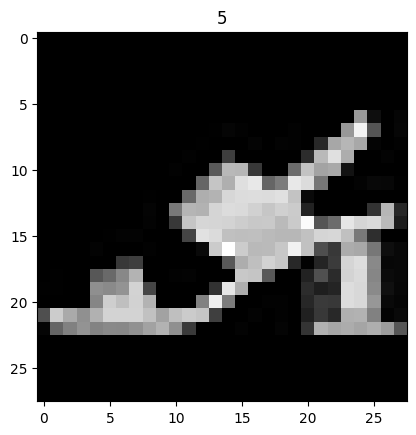

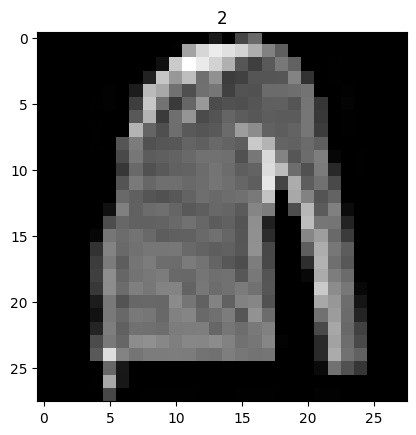

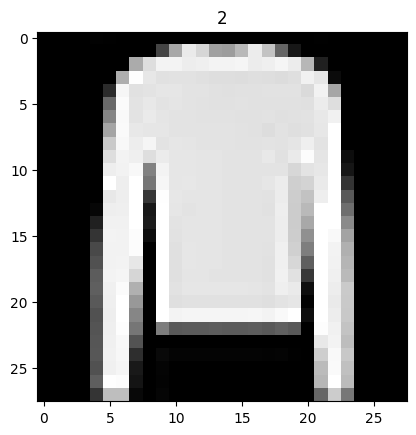

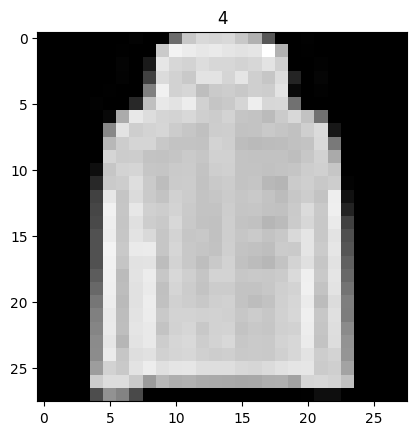

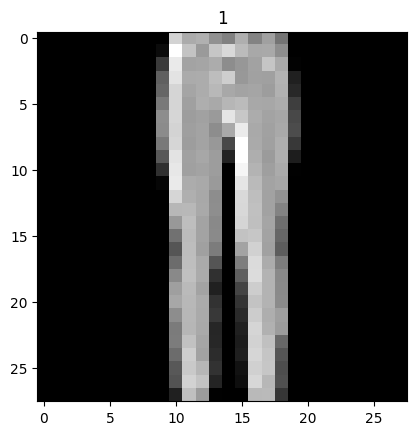

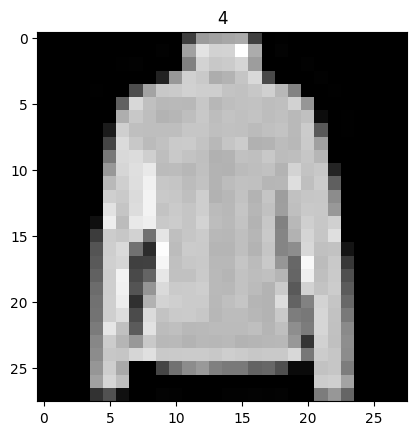

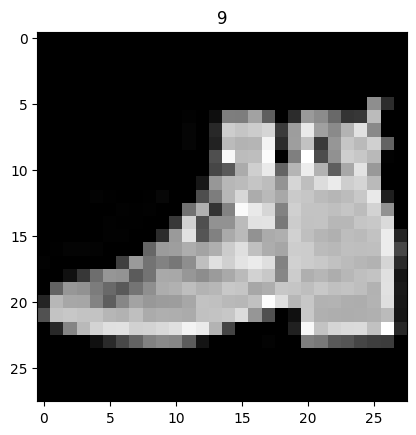

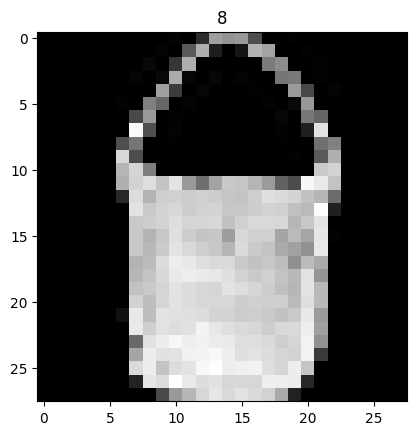

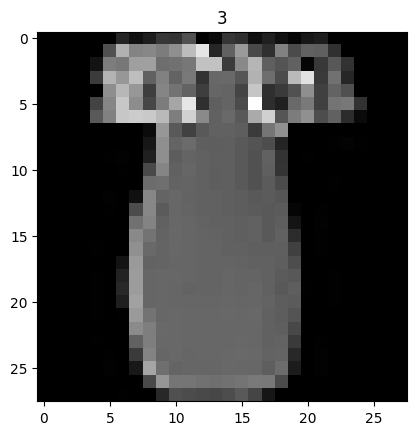

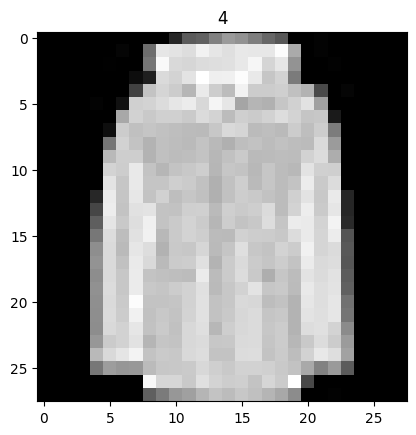

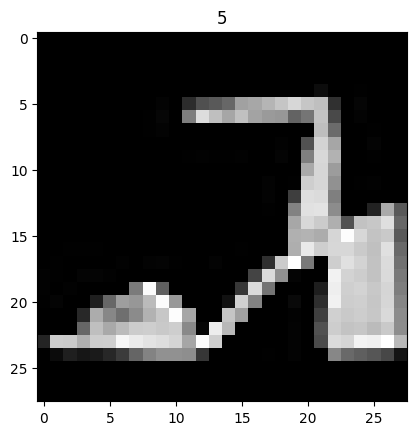

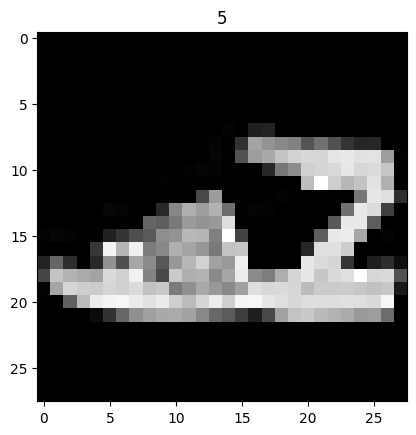

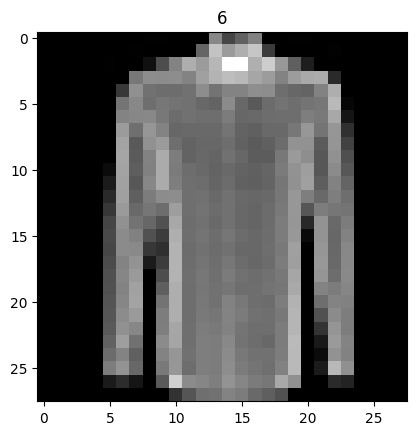

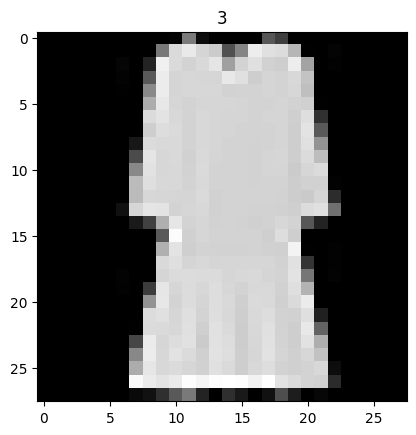

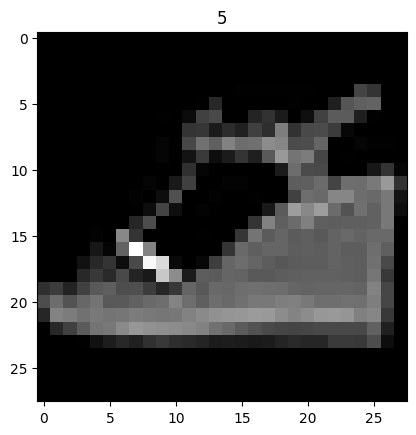

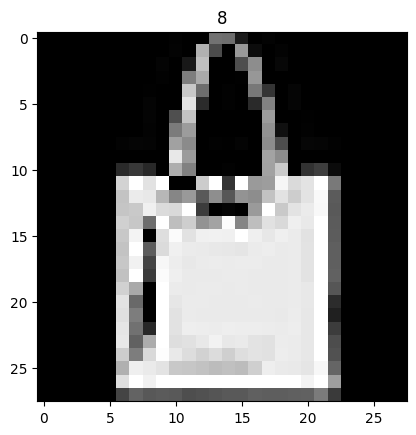

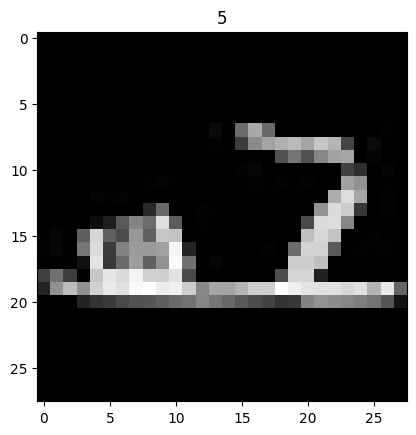

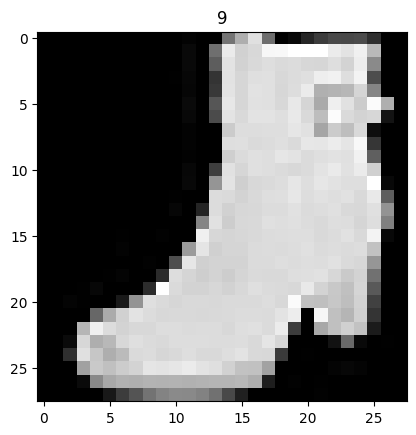

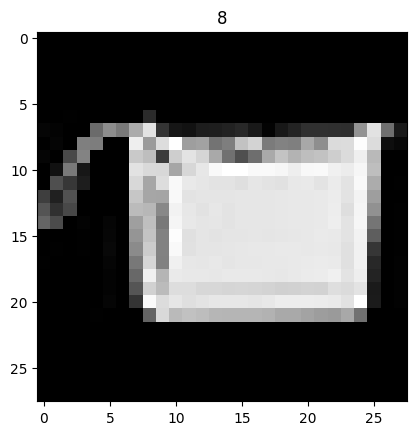

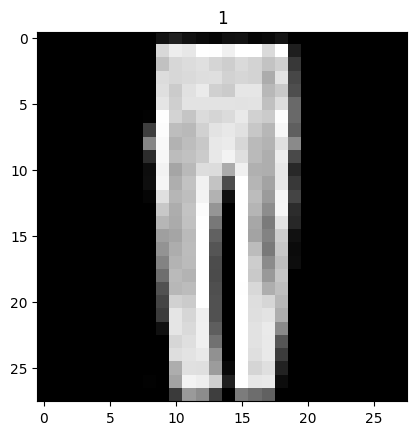

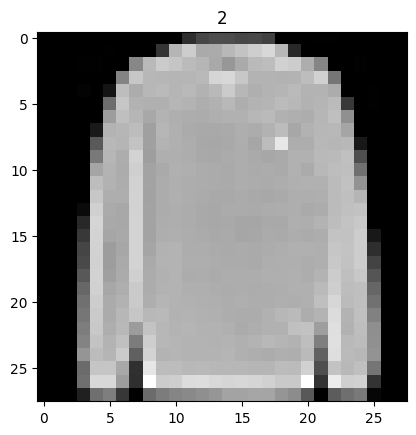

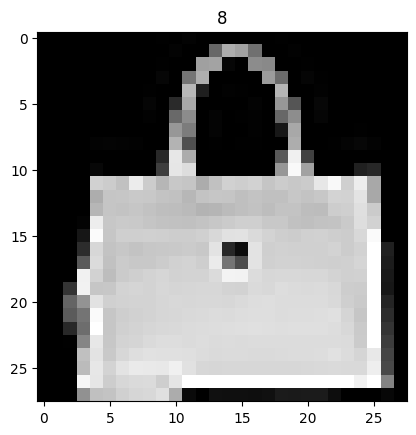

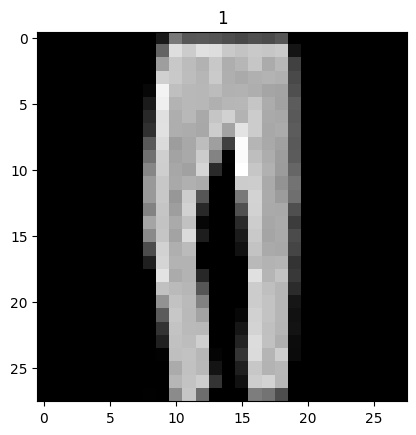

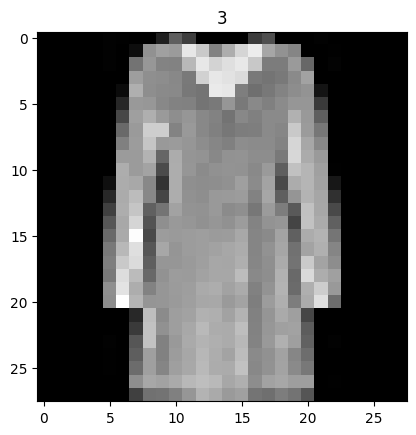

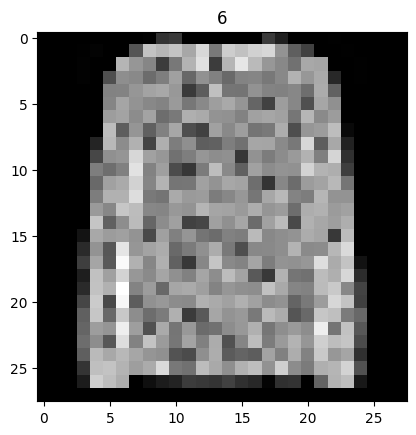

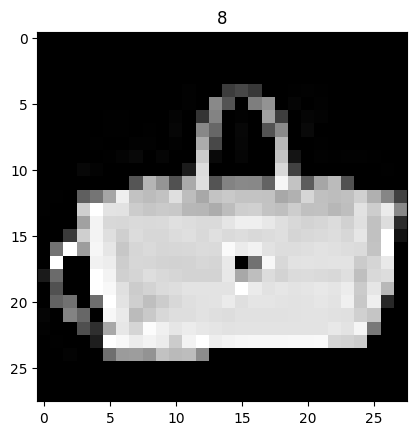

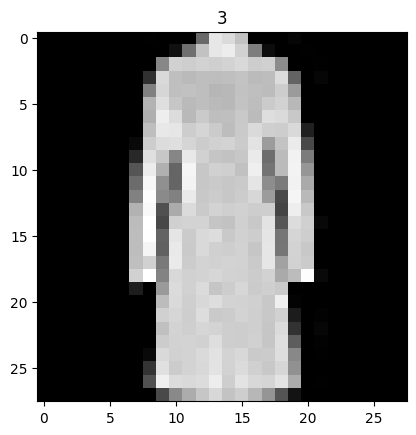

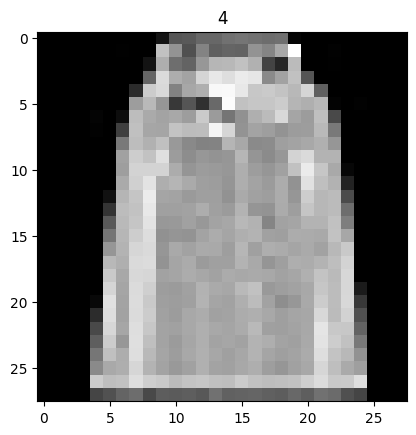

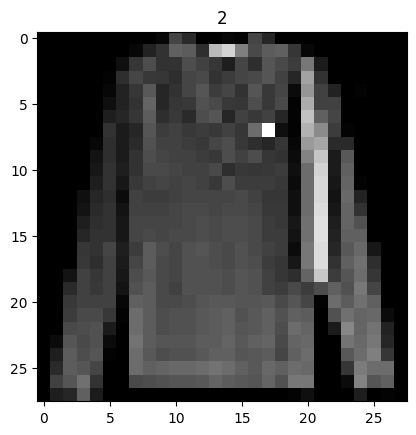

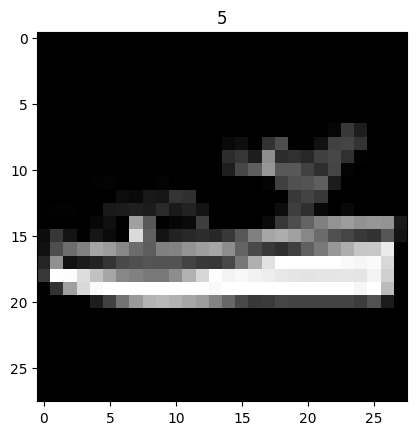

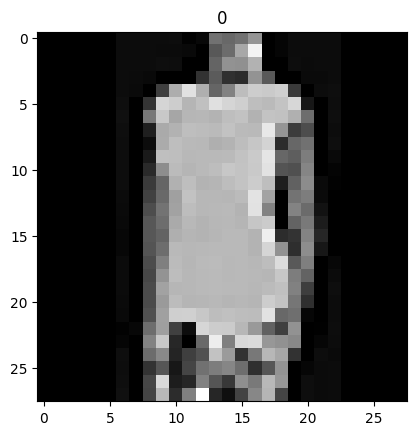

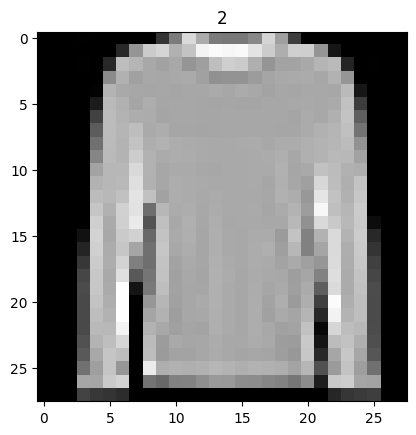

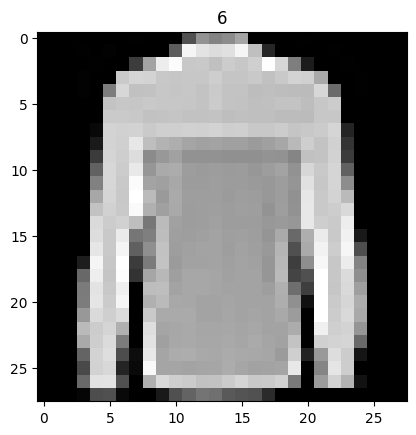

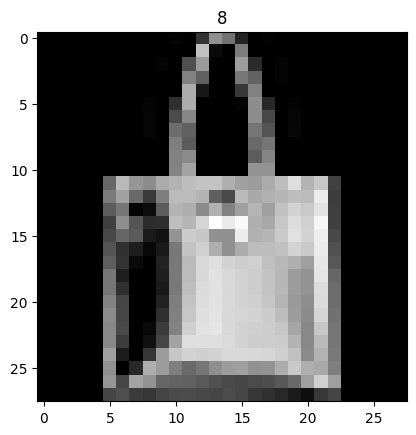

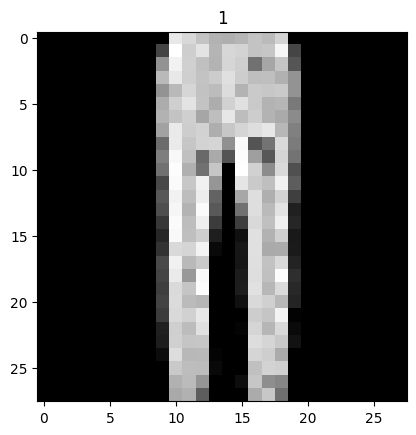

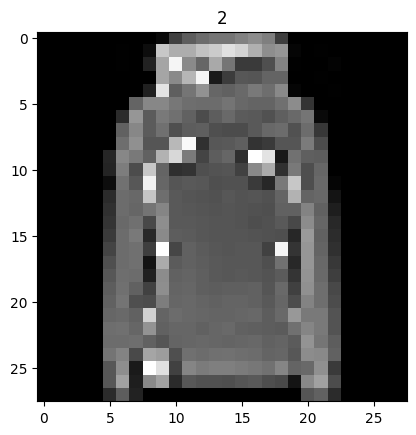

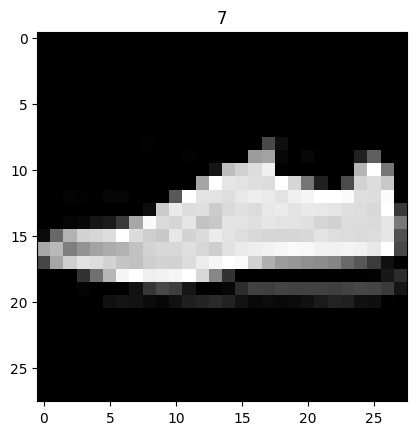

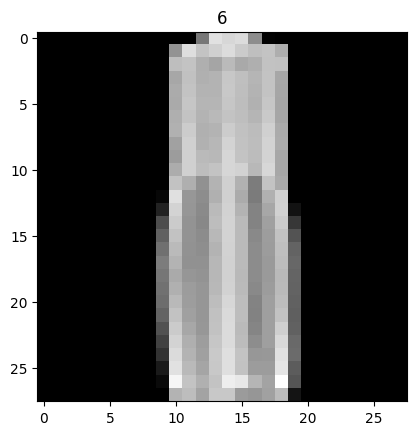

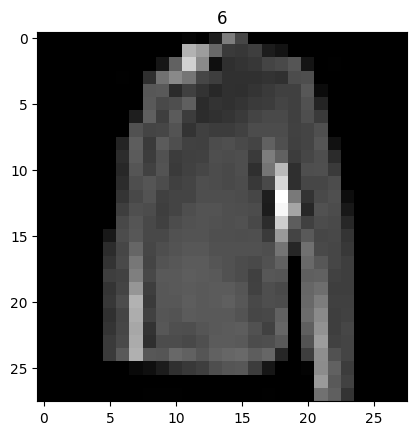

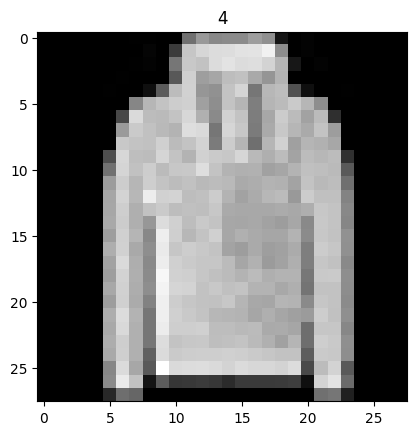

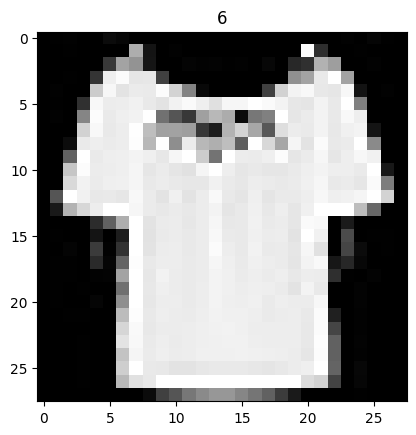

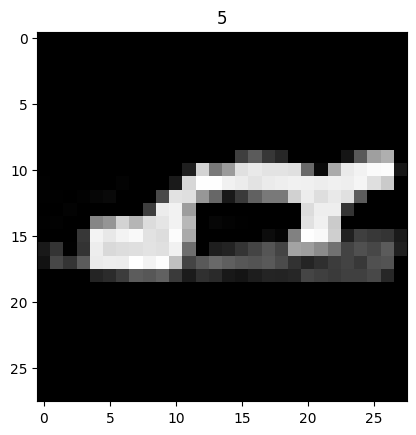

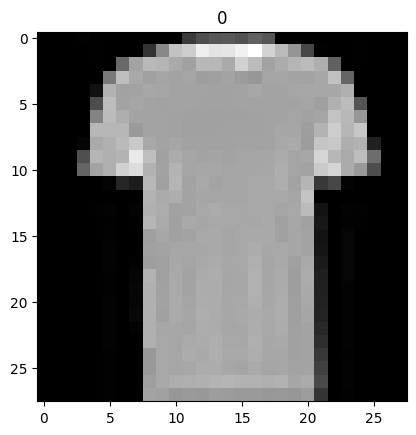

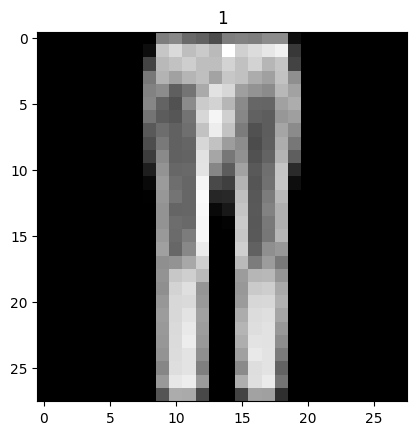

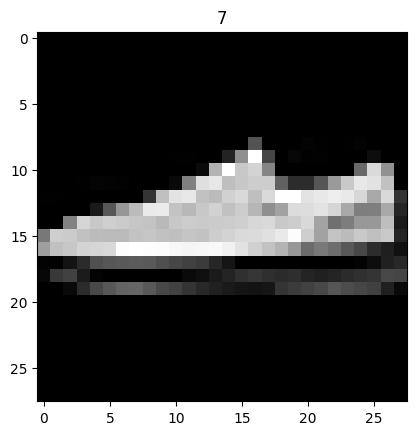

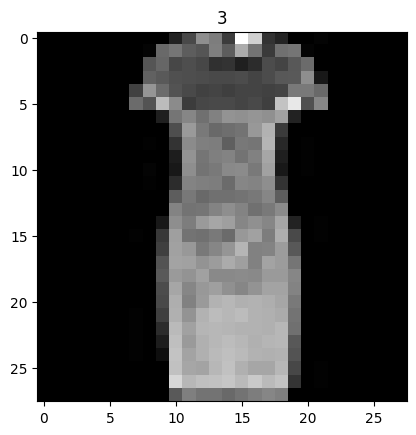

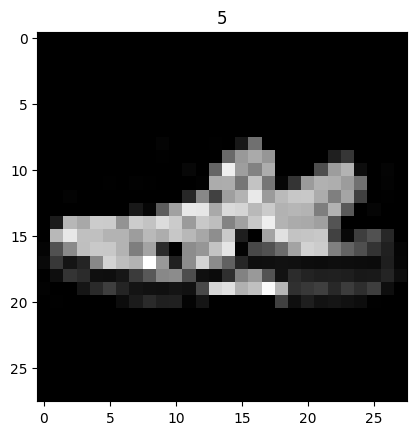

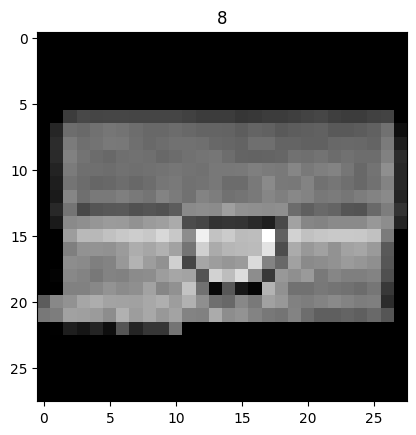

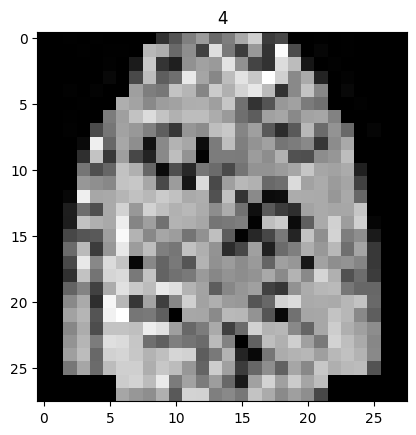

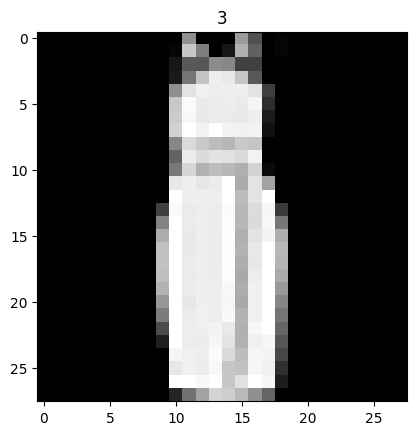

In [39]:
for i in range(100):
    plt.imshow(train_x[i].reshape(28,28),cmap='gray')
    plt.title(train_y[i])
    plt.show()

In [40]:
# 2-pullover, 9-ankle_boot ,6-shirt, 0-tshirt,3-dress,4-coat,5-sandal,8-bag,7-sneaker,1-trouser

# #label_names = {
#     0:'t_shirt',
#     1:'trouser',
#     2:'pullover',
#     3:'dress',
#     4:'coat',
#     5:'sandal',
#     6:'shirt',
#     7:'sneaker',
#     8:'bag',
#     9:'ankle_boot'
# }

In [41]:
label_names = ['t_shirt', 'trouser', 'pullover', 'dress', 'coat',
               'sandal', 'shirt', 'sneaker', 'bag', 'ankle_boot']

In [42]:
def predict(id_):
    prediction=model.predict(test_x[id_:id_+1])
    predicted_label=label_names[np.argmax(prediction)]
    print("Predicted:", predicted_label)
    plt.imshow(test_x[id_].reshape(28,28),cmap='gray')
    plt.axis('off')
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
Predicted: dress


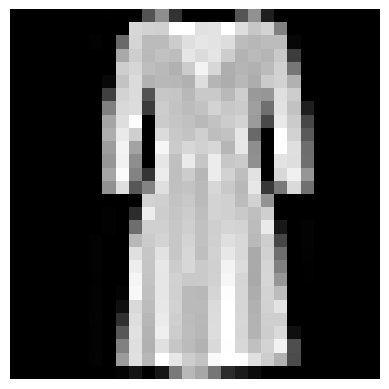

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Predicted: pullover


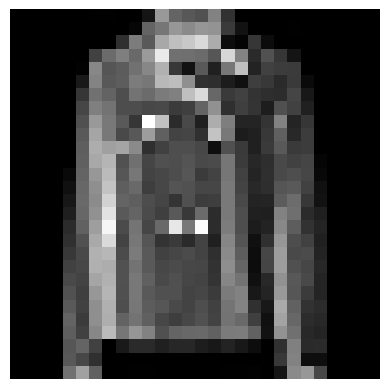

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Predicted: coat


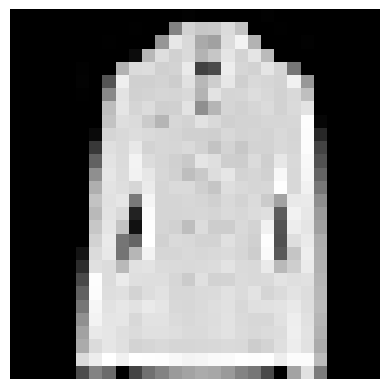

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Predicted: shirt


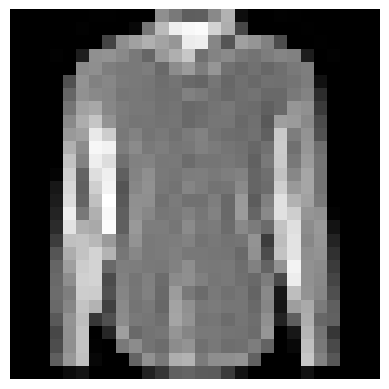

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Predicted: bag


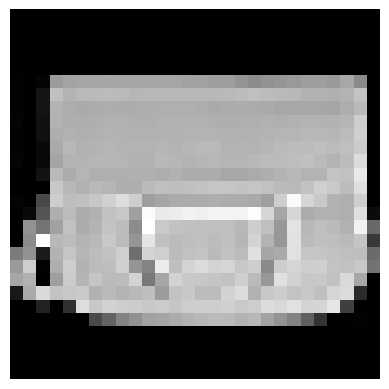

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Predicted: sandal


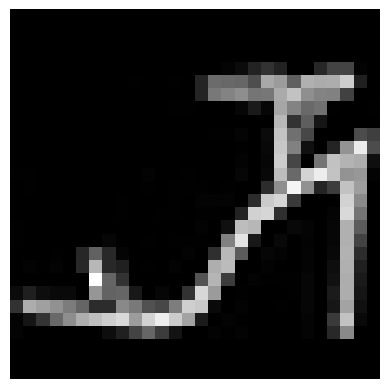

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Predicted: shirt


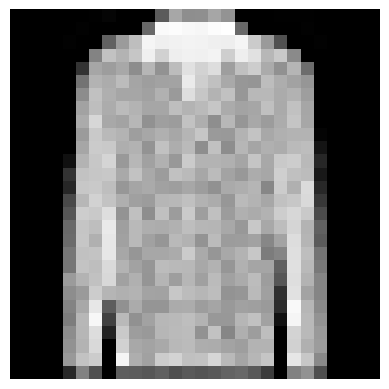

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Predicted: dress


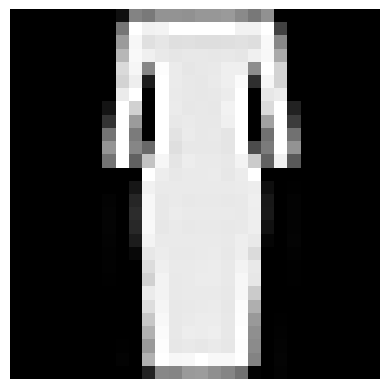

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Predicted: shirt


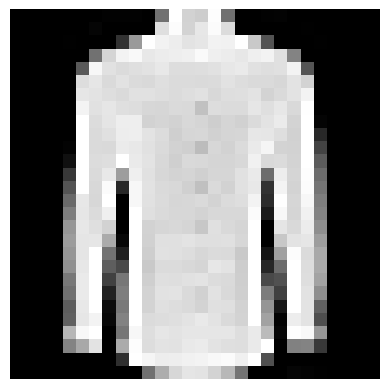

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Predicted: coat


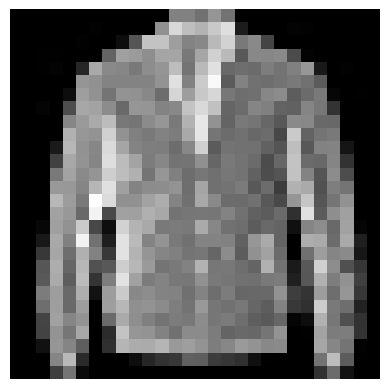

In [43]:
for i in range(10,20):
    predict(i)